In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, log_loss , confusion_matrix
import joblib

In [9]:
df = pd.read_csv('../../data/interim/olist_ml_processed_dataset.csv')

X_raw = df.drop(columns=['actual_delivery_days', 'delivery_status', 'delivery_label']).values
y_raw = df['delivery_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Features go to float32; labels go to long (integers) for CrossEntropyLoss
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# --- Step 4: Create DataLoaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 256  # Adjust this depending on your preferences

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True          # Shuffle training data to help generalization
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False          # No need to shuffle test/evaluation data
)

print(f"DataLoaders successfully created!")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

DataLoaders successfully created!
Train batches: 271 | Test batches: 68


In [10]:
# Model initialization
xgb_model = XGBClassifier(
    n_estimators=1000,
    objective='multi:softprob',
    num_class=6,
    random_state=42,
    n_jobs=-1
)
# Train using your raw arrays
print("Training XGBoost Classifier...")
xgb_model.fit(X_train, y_train)

Training XGBoost Classifier...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [11]:
predicted_classes = xgb_model.predict(X_test)
predicted_probs = xgb_model.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, predicted_classes)
precision = precision_score(y_test, predicted_classes, average='weighted', zero_division=0)
f1 = f1_score(y_test, predicted_classes, average='weighted', zero_division=0)

# --- Integrated Loss Tracking ---
# 1. Cross Entropy Loss (Log Loss)
test_loss = log_loss(y_test, predicted_probs)

# 2. Inline Huber Loss Calculation (delta = 1.0)
delta = 1.0
error = y_test - predicted_classes
abs_error = np.abs(error)

huber_loss = np.mean(
    np.where(abs_error <= delta, 0.5 * (error ** 2), delta * (abs_error - 0.5 * delta))
)

# --- Print Text Report ---
print("\n" + "="*55)
print("         OLIST 6-CLASS XGBOOST PERFORMANCE REPORT         ")
print("="*55)
print(f"Overall Accuracy:   {accuracy * 100:.2f}%")
print(f"Weighted Precision:  {precision * 100:.2f}%")
print(f"Weighted F1-Score:   {f1 * 100:.2f}%")
print("-"*55)
print(f"Cross-Entropy Loss:  {test_loss:.4f}")
print(f"Huber Loss:          {huber_loss:.4f}")
print("="*55)

print("\nDetailed Performance Breakdown Across All 6 Classes:")
print(classification_report(y_test, predicted_classes, zero_division=0))


         OLIST 6-CLASS XGBOOST PERFORMANCE REPORT         
Overall Accuracy:   48.96%
Weighted Precision:  49.24%
Weighted F1-Score:   48.99%
-------------------------------------------------------
Cross-Entropy Loss:  1.3276
Huber Loss:          0.4184

Detailed Performance Breakdown Across All 6 Classes:
              precision    recall  f1-score   support

           0       0.58      0.53      0.56      1805
           1       0.45      0.45      0.45      3503
           2       0.43      0.43      0.43      3920
           3       0.48      0.55      0.51      4410
           4       0.52      0.46      0.49      2449
           5       0.63      0.55      0.59      1219

    accuracy                           0.49     17306
   macro avg       0.52      0.50      0.51     17306
weighted avg       0.49      0.49      0.49     17306



In [12]:
model_save_path = '../../data/model/XGBoost_Model.pkl'
joblib.dump(xgb_model, model_save_path)
print(f"Model saved successfully to '{model_save_path}'\n")

Model saved successfully to '../../data/model/XGBoost_Model.pkl'



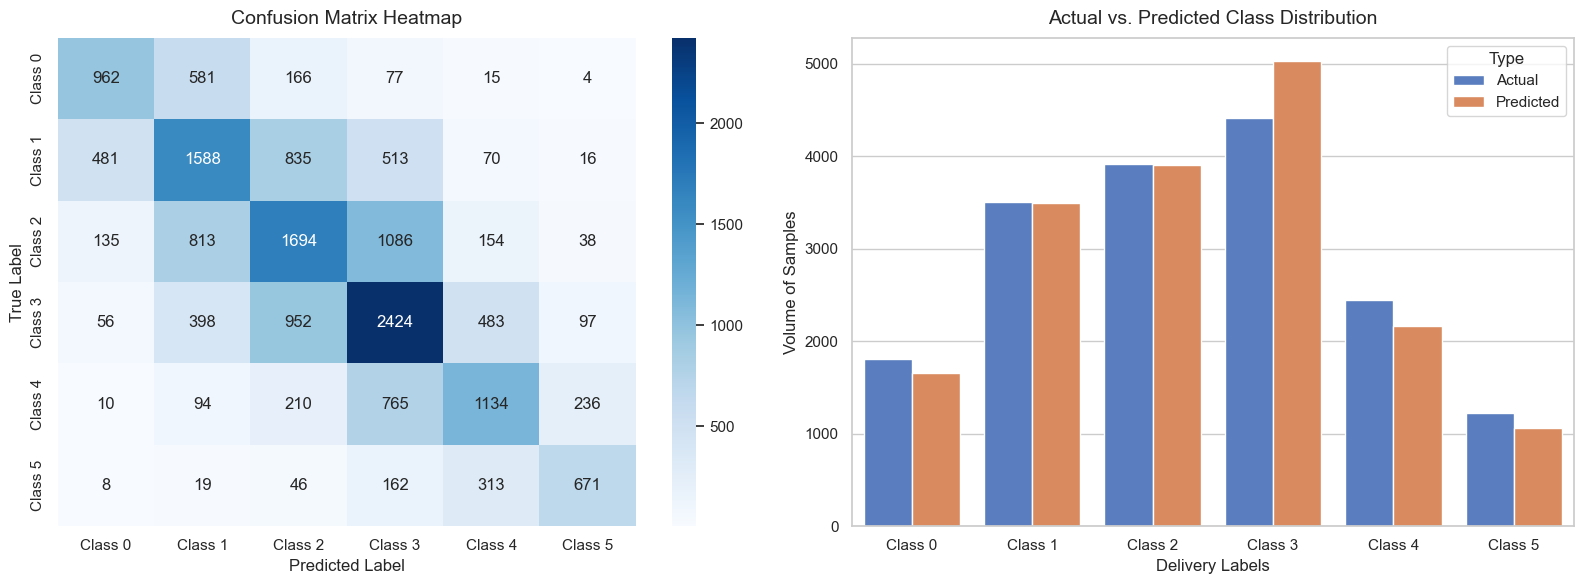

In [13]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predicted_classes)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    ax=axes[0],
    xticklabels=[f'Class {i}' for i in range(6)],
    yticklabels=[f'Class {i}' for i in range(6)]
)
axes[0].set_title('Confusion Matrix Heatmap', fontsize=14, pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Plot B: Actual vs Predicted Class Distribution Comparison
unique, counts_actual = np.unique(y_test, return_counts=True)
unique_pred, counts_pred = np.unique(predicted_classes, return_counts=True)

# Ensure all 6 classes are mapped even if 0 predictions occurred for a minority class
dict_actual = dict(zip(unique, counts_actual))
dict_pred = dict(zip(unique_pred, counts_pred))
data_dist = {
    'Class': [f'Class {i}' for i in range(6)] * 2,
    'Count': [dict_actual.get(i, 0) for i in range(6)] + [dict_pred.get(i, 0) for i in range(6)],
    'Type': ['Actual'] * 6 + ['Predicted'] * 6
}
df_dist = pd.DataFrame(data_dist)

sns.barplot(x='Class', y='Count', hue='Type', data=df_dist, palette='muted', ax=axes[1])
axes[1].set_title('Actual vs. Predicted Class Distribution', fontsize=14, pad=10)
axes[1].set_xlabel('Delivery Labels', fontsize=12)
axes[1].set_ylabel('Volume of Samples', fontsize=12)

plt.tight_layout()
plt.show()